# Artificial and Computational Intelligence Assignment 1

## Problem solving by Informed Search and/or Local Search

**Mandatory Detail: The Word  document and IPYNB FILE must include:**

o	BITS IDs of all team members

o	Their individual contribution percentages






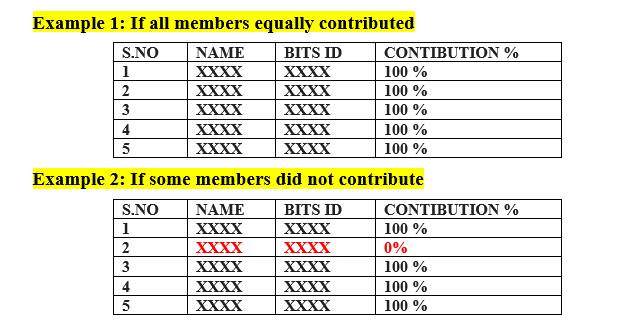

Things to follow
1.	Use appropriate data structures to represent the graph and the path using python libraries
2.	Provide proper documentation
3.	Find the path and print it

Coding begins here

### 1.	Define the environment in the following block

List the PEAS decription of the problem here in this markdown block

Design the agent as PSA Agent(Problem Solving Agent)
Clear Initial data structures to define the graph and variable declarations is expected
IMPORTATANT: Write distinct code block as below

In [10]:
import numpy as np
import random
import matplotlib.pyplot as plt
from copy import deepcopy

In [11]:
#Code Block : Set Initial State (Must handle dynamic inputs)
class AntColonyOptimization:
    def __init__(self, weights, values, capacity, n_ants, alpha, beta, evaporation_rate=0.1, max_iterations=100):
        self.weights = np.array(weights)
        self.values = np.array(values)
        self.capacity = capacity
        self.n_items = len(weights)
        self.n_ants = n_ants
        self.alpha = alpha  # Pheromone importance
        self.beta = beta    # Heuristic importance (distance/desirability)
        self.evaporation_rate = evaporation_rate
        self.max_iterations = max_iterations

        # Initialize pheromone matrix (items x position in selection order)
        self.pheromones = np.ones((self.n_items, self.n_items)) * 0.1

        # Calculate heuristic information (value/weight ratio)
        self.heuristic = self.values / self.weights

        # Track best solution
        self.best_solution = None
        self.best_value = 0
        self.convergence_history = []

    def construct_solution(self, ant_id):
        """Construct a solution for one ant"""
        solution = np.zeros(self.n_items, dtype=int)
        remaining_capacity = self.capacity
        available_items = list(range(self.n_items))
        selection_order = []

        while available_items and remaining_capacity > 0:
            # Calculate probabilities for available items
            probabilities = self.calculate_probabilities(available_items, remaining_capacity)

            if not probabilities:
                break

            # Select item based on probabilities
            selected_idx = np.random.choice(len(available_items), p=probabilities)
            selected_item = available_items[selected_idx]

            # Add item if it fits
            if self.weights[selected_item] <= remaining_capacity:
                solution[selected_item] = 1
                remaining_capacity -= self.weights[selected_item]
                selection_order.append(selected_item)

            # Remove selected item from available items
            available_items.remove(selected_item)

        return solution, selection_order

    def calculate_probabilities(self, available_items, remaining_capacity):
        """Calculate selection probabilities for available items"""
        if not available_items:
            return []

        # Filter items that can fit
        feasible_items = [item for item in available_items if self.weights[item] <= remaining_capacity]

        if not feasible_items:
            return []

        # Calculate probability components
        probabilities = []
        for item in feasible_items:
            # Pheromone component (average pheromone for this item)
            pheromone_value = np.mean(self.pheromones[item, :])

            # Heuristic component (value/weight ratio)
            heuristic_value = self.heuristic[item]

            # Combined probability
            prob = (pheromone_value ** self.alpha) * (heuristic_value ** self.beta)
            probabilities.append(prob)

        # Normalize probabilities
        total_prob = sum(probabilities)
        if total_prob > 0:
            probabilities = [p / total_prob for p in probabilities]
        else:
            probabilities = [1.0 / len(feasible_items)] * len(feasible_items)

        # Map back to available_items indices
        full_probabilities = []
        feasible_idx = 0
        for item in available_items:
            if item in feasible_items:
                full_probabilities.append(probabilities[feasible_idx])
                feasible_idx += 1
            else:
                full_probabilities.append(0.0)

        # Normalize again
        total_prob = sum(full_probabilities)
        if total_prob > 0:
            full_probabilities = [p / total_prob for p in full_probabilities]

        return full_probabilities

    def evaluate_solution(self, solution):
        """Evaluate the quality of a solution"""
        total_weight = np.sum(solution * self.weights)
        total_value = np.sum(solution * self.values)

        if total_weight <= self.capacity:
            return total_value
        else:
            return 0  # Infeasible solution

    def update_pheromones(self, solutions, values):
        """Update pheromone trails based on ant solutions"""
        # Evaporation
        self.pheromones *= (1 - self.evaporation_rate)

        # Add pheromones based on solution quality
        for i, (solution, selection_order) in enumerate(solutions):
            if values[i] > 0:  # Only update for feasible solutions
                # Pheromone deposit proportional to solution quality
                deposit = values[i] / self.best_value if self.best_value > 0 else 1.0

                # Update pheromones for selected items
                for pos, item in enumerate(selection_order):
                    self.pheromones[item, pos] += deposit

    def optimize(self):
        """Main ACO optimization loop"""
        print(f"Starting ACO with {self.n_ants} ants, alpha={self.alpha}, beta={self.beta}")
        print("=" * 60)

        for iteration in range(self.max_iterations):
            # Generate solutions for all ants
            solutions = []
            values = []

            for ant in range(self.n_ants):
                solution, selection_order = self.construct_solution(ant)
                value = self.evaluate_solution(solution)
                solutions.append((solution, selection_order))
                values.append(value)

                # Update best solution
                if value > self.best_value:
                    self.best_value = value
                    self.best_solution = solution.copy()

            # Update pheromones
            self.update_pheromones(solutions, values)

            # Track convergence
            self.convergence_history.append(self.best_value)

            # Print progress
            if iteration % 10 == 0 or iteration == self.max_iterations - 1:
                avg_value = np.mean(values)
                print(f"Iteration {iteration:3d}: Best = {self.best_value:2d}, Average = {avg_value:5.2f}")

        return self.best_solution, self.best_value

    def print_results(self, scenario_name):
        """Print detailed results"""
        print(f"\n=== {scenario_name} RESULTS ===")
        if self.best_solution is not None:
            selected_items = [i+1 for i, selected in enumerate(self.best_solution) if selected]
            total_weight = np.sum(self.best_solution * self.weights)

            print(f"Best Value: {self.best_value}")
            print(f"Total Weight: {total_weight}/{self.capacity} kg")
            print(f"Selected Items: {selected_items}")
            print(f"Item Details:")

            for i, selected in enumerate(self.best_solution):
                if selected:
                    print(f"  Item {i+1}: Weight={self.weights[i]}, Value={self.values[i]}, "
                          f"Efficiency={self.values[i]/self.weights[i]:.2f}")

        print(f"Convergence: Reached best value at iteration {len(self.convergence_history) - 1 - self.convergence_history[::-1].index(self.best_value)}")

In [12]:
#Code Block : Set the matrix for transition & cost (as relevant for the given problem)

In [13]:
#Code Block : Write function to design the Transition Model/Successor function. Ideally this would be called while search algorithms are implemented

In [14]:
#Code block : Write fucntion to handle goal test (Must handle dynamic inputs). Ideally this would be called while search algorithms are implemented

### 2.	Definition of Algorithm  (Mention the Name of the algorithm )

In [15]:
#Code Block : Function for algorithm 1 implementation
def run_aco_scenarios(weights, values, capacity):
    """Run both ACO scenarios and compare results"""
    # Problem data
    # weights = [10, 6, 4, 8, 2, 7, 5, 1]
    # values = [2, 3, 1, 6, 4, 5, 8, 7]
    # capacity = 20

    # Scenario 1
    print("SCENARIO 1: 3 Ants, Alpha=0.5, Beta=3")
    aco1 = AntColonyOptimization(weights, values, capacity, n_ants=3, alpha=0.5, beta=3, max_iterations=50)
    solution1, value1 = aco1.optimize()
    aco1.print_results("SCENARIO 1")

    print("\n" + "="*80 + "\n")

    # Scenario 2
    print("SCENARIO 2: 5 Ants, Alpha=0.5, Beta=7")
    aco2 = AntColonyOptimization(weights, values, capacity, n_ants=5, alpha=0.5, beta=7, max_iterations=50)
    solution2, value2 = aco2.optimize()
    aco2.print_results("SCENARIO 2")

    # Comparison
    print("\n" + "="*80)
    print("COMPARISON AND ANALYSIS")
    print("="*80)

    print(f"Scenario 1 Result: Value = {value1}")
    print(f"Scenario 2 Result: Value = {value2}")
    print(f"Optimal Solution (DP): Value = 24")

    # Calculate efficiency ratios for reference
    efficiency = [values[i]/weights[i] for i in range(len(weights))]
    sorted_items = sorted(range(len(weights)), key=lambda i: efficiency[i], reverse=True)

    print(f"\nItem Efficiency Rankings (Value/Weight):")
    for rank, item in enumerate(sorted_items):
        print(f"  {rank+1}. Item {item+1}: Efficiency = {efficiency[item]:.2f}")

    # Plot convergence
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(aco1.convergence_history, 'b-', label='Scenario 1', linewidth=2)
    plt.plot(aco2.convergence_history, 'r-', label='Scenario 2', linewidth=2)
    plt.axhline(y=24, color='g', linestyle='--', label='Optimal (DP)')
    plt.xlabel('Iteration')
    plt.ylabel('Best Value Found')
    plt.title('ACO Convergence Comparison')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    # Pheromone visualization for final state
    plt.imshow(aco2.pheromones, cmap='viridis', aspect='auto')
    plt.colorbar(label='Pheromone Intensity')
    plt.xlabel('Selection Position')
    plt.ylabel('Item Index')
    plt.title('Final Pheromone Distribution (Scenario 2)')

    plt.tight_layout()
    plt.show()

    return aco1, aco2

### DYNAMIC INPUT

IMPORTANT : Dynamic Input must be got in this section. Display the possible states to choose from:
This is applicable for all the relevent problems as mentioned in the question.

In [16]:
#Code Block : Function & call to get inputs (start/end state)
weights = [int(item) for item in input("Enter 10 weights (comma separated) : ").split(',')]
values = [int(item) for item in input("Enter 10 values (comma separated) : ").split(',')]
capacity = int(input("Enter capacity value: "))

### 4.	Calling the search algorithms

SCENARIO 1: 3 Ants, Alpha=0.5, Beta=3
Starting ACO with 3 ants, alpha=0.5, beta=3
Iteration   0: Best = 26, Average = 25.33
Iteration  10: Best = 26, Average = 25.33
Iteration  20: Best = 26, Average = 26.00
Iteration  30: Best = 26, Average = 25.67
Iteration  40: Best = 26, Average = 26.00
Iteration  49: Best = 26, Average = 25.33

=== SCENARIO 1 RESULTS ===
Best Value: 26
Total Weight: 20/20 kg
Selected Items: [3, 4, 5, 7, 8]
Item Details:
  Item 3: Weight=4, Value=1, Efficiency=0.25
  Item 4: Weight=8, Value=6, Efficiency=0.75
  Item 5: Weight=2, Value=4, Efficiency=2.00
  Item 7: Weight=5, Value=8, Efficiency=1.60
  Item 8: Weight=1, Value=7, Efficiency=7.00
Convergence: Reached best value at iteration 49


SCENARIO 2: 5 Ants, Alpha=0.5, Beta=7
Starting ACO with 5 ants, alpha=0.5, beta=7
Iteration   0: Best = 26, Average = 25.00
Iteration  10: Best = 26, Average = 25.40
Iteration  20: Best = 26, Average = 25.40
Iteration  30: Best = 26, Average = 26.00
Iteration  40: Best = 26, Ave

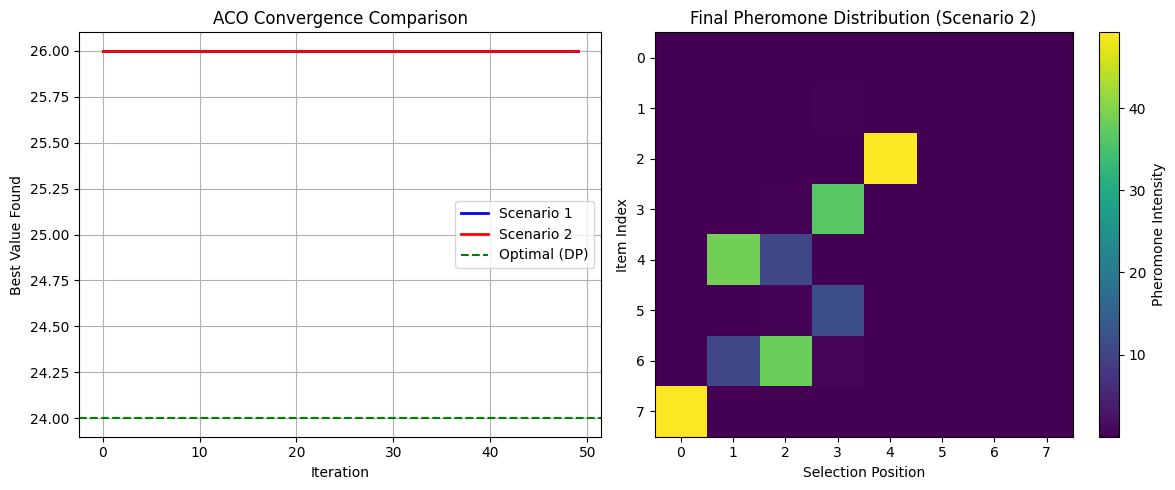

In [17]:
aco1, aco2 = run_aco_scenarios(weights, values, capacity)

# 5.	Comparitive Analysis

In [18]:
#Code Block : Print the Time & Space complexity of algorithm